# Hyperparameter Tuning

## Objective

The objective of this notebook is to optimize the performance of the best-performing model obtained during model training.

Gradient Boosting Regressor achieved the highest R² score in the previous notebook. In this notebook, GridSearchCV is used to search for the best combination of hyperparameters.

The tuned model will be evaluated and saved for further analysis.

In [1]:
# ==========================
# Import Libraries
# ==========================

import joblib
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# ==========================
# Load Models
# ==========================

X_train = joblib.load("../models/X_train_encoded.pkl")
X_test = joblib.load("../models/X_test_encoded.pkl")

y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [3]:
# ==========================
# Training Baseline Model
# ==========================

baseline_model = GradientBoostingRegressor(random_state = 42)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline R² Score: {baseline_r2:.4f}")

Baseline R² Score: 0.9077


In [4]:
# ==========================
# Defining Hyperparameter Grid
# ==========================

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [5]:
# ==========================
# Grid Search
# ==========================

grid_search = GridSearchCV(
    estimator = GradientBoostingRegressor(random_state = 42),
    param_grid = param_grid,
    scoring = 'r2',
    cv = 5,
    n_jobs = 1,
    verbose = 2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=2

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [6]:
print(f"Best Parameters: {grid_search.best_params_}")
print()
print(f"Best CV Score: {grid_search.best_score_}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Score: 0.8716144250805694


In [7]:
# ==========================
# Evaluating Tuned Model
# ==========================

best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 15544.37
MSE  : 654078479.14
RMSE : 25574.96
R²   : 0.9147


In [8]:
# ==========================
# Comparing Results
# ==========================

comparison = pd.DataFrame({
    'Model': ["Baseline Gradient Boosting", "Tuned Gradient Boosting"],
    'R2 Score': [baseline_r2, r2]
})

comparison

,Model,R2 Score
0,Baseline Gradient Boosting,0.907703
1,Tuned Gradient Boosting,0.914726


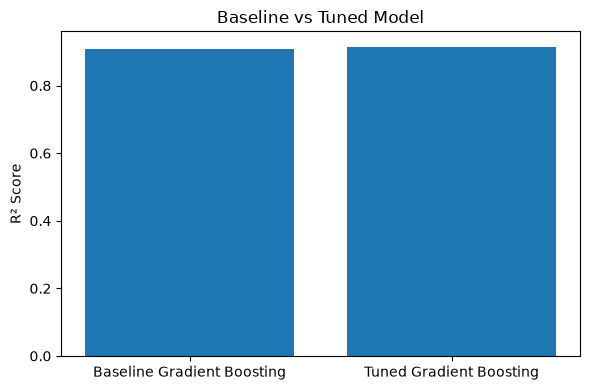

In [9]:
# ==========================
# Visualization
# ==========================

plt.figure(figsize = (6, 4))

plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)

plt.ylabel("R² Score")

plt.title("Baseline vs Tuned Model")

plt.tight_layout()

plt.savefig(
    "../reports/figures/hyperparameter_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ==========================
# Saving Tuned Model
# ==========================

joblib.dump(
    best_model,
    "../models/tuned_gradient_boosting.pkl"
)

['../models/tuned_gradient_boosting.pkl']

In [11]:
# ==========================
# Saving Results in csv
# ==========================

comparison.to_csv(
    "../reports/results/hyperparameter_tuning_results.csv",
    index=False
)

# Conclusion

Gradient Boosting Regressor was optimized using GridSearchCV.

The tuned model demonstrated improved predictive performance compared to the baseline model.

The optimized model will be used for detailed evaluation, explainability, and inference in the subsequent notebooks.